# Περιγραφή Προβλήματος & Dataset
### Το πρόβλημα αφορά την πρόβλεψη της τελικής αξίας ενός χρήστη (Conversion Prediction) για τη δική μας υπηρεσία (ιστότοπο), με βάση τη συμπεριφορά του κατά τη διάρκεια μιας επίσκεψης.

# Η Κατάσταση & η Καταγραφή
### Ένας χρήστης επισκέπτεται τον ιστότοπο (ο οποίος πουλά συνδρομητικές υπηρεσίες).Εμείς καταγράφουμε τα εξής:

### Το Προφίλ του Χρήστη:

*   Age (Ηλικία) και Device (Συσκευή, π.χ., Mobile)
*   Subscription: Το ήδη υπάρχον καθεστώς μέλους του χρήστη (Basic, Premium, ή VIP).
### Τη Συμπεριφορά του (Interaction Features):
*   Time_Spent_min (Πόσο χρόνο έμεινε)
*   Pages_Viewed (Πόσες σελίδες είδε)
*   Ad_Clicked_Count (Πόσες διαφημίσεις πάτησε εντός του δικού μας site).

# Ο Στόχος του Μοντέλου (Conversion_Type)
Χρησιμοποιούμε όλα τα παραπάνω ως Χαρακτηριστικά (**X**) για να προβλέψουμε το Τελικό Αποτέλεσμα (**y**) της επίσκεψης, το οποίο είναι η **Μεταβλητή Στόχος** (Conversion_Type):

*   None: Ο χρήστης έφυγε χωρίς ενέργεια.
*   Trial: Ο χρήστης έκανε εγγραφή για δωρεάν δοκιμή.
*   Full_Sale: Ο χρήστης έκανε πληρωμή (π.χ., αγόρασε ένα πρόσθετο, αναβάθμισε το πακέτο του, ή έκανε αρχική αγορά).

# Η Πρόκληση του Feature Engineering
Η πρόκληση του Feature Engineering είναι να μετατρέψουμε τις αρχικές μετρήσεις (Time, Pages, Subscription) σε πιο ισχυρούς προβλεπτικούς παράγοντες, όπως:

*   Engagement\_Rate (Pages/Time): Ρυθμός Κατανάλωσης Περιεχομένου.
*   Monetary_Score: Δυνητική οικονομική βαρύτητα του χρήστη.
*   Is_Heavy_Ad_Clicker: Ένα Flag που απομονώνει τους χρήστες με ακραία συμπεριφορά σε κλικς.

# BLOCK 1: Προετοιμασία & Ενσωμάτωση Προηγούμενων Τεχνικών
## 1.1. Δημιουργία, Καθαρισμός ($\text{NaN}$) & Κωδικοποίηση Dataset
### Στόχος: Δημιουργία $\text{N}=10$ dataset, συμπλήρωση $\text{NaN}$ (Age) και κωδικοποίηση κατηγορικών μεταβλητών.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Ρύθμιση για αναπαραγωγιμότητα και μικρό μέγεθος
np.random.seed(42)
N = 10

data = {
    'User_ID': range(2001, 2001 + N),
    # Time_Spent_min & Pages_Viewed: Συσχετισμένα
    'Time_Spent_min': [10.5, 5.2, 25.0, 15.8, 8.0, 32.1, 12.5, 4.5, 18.0, 6.1],
    'Pages_Viewed': [12, 6, 28, 16, 9, 35, 14, 5, 20, 7],
    # Age: Περιέχει 1 NaN και 1 Outlier (75)
    'Age': [35.0, 48.0, np.nan, 22.0, 60.0, 45.0, 75.0, 28.0, 31.0, 52.0],
    # Subscription (Ordinal): Basic=0, Premium=1, VIP=2
    'Subscription': ['Basic', 'Premium', 'VIP', 'Basic', 'Premium', 'VIP', 'Basic', 'Basic', 'Premium', 'VIP'],
    # Ad_Clicked_Count: Περιέχει 1 Outlier (20)
    'Ad_Clicked_Count': [1, 3, 0, 2, 5, 4, 1, 0, 20, 2],
    'Device': ['Mobile', 'Desktop', 'Mobile', 'Tablet', 'Desktop', 'Mobile', 'Tablet', 'Mobile', 'Desktop', 'Mobile'],
    'Conversion_Type': ['Trial', 'Full_Sale', 'None', 'Trial', 'Full_Sale', 'Full_Sale', 'None', 'None', 'Trial', 'Full_Sale']
}
df = pd.DataFrame(data)

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
print("🔹 Αρχικό Dataset (N=10) & Ελλείψεις:\n", df)
print("\nΕλλείψεις ανά στήλη:\n", df.isnull().sum())

# 1. Imputation Age (με Median)
imputer_median = SimpleImputer(strategy='median')
df['Age'] = imputer_median.fit_transform(df[['Age']])

# 2. Ordinal Encoding (Subscription)
subscription_order = ['Basic', 'Premium', 'VIP']
encoder_ord = OrdinalEncoder(categories=[subscription_order])
df['Subscription_Encoded'] = encoder_ord.fit_transform(df[['Subscription']])
df_encoded = df.drop(columns=['Subscription'])

# 3. One-Hot Encoding (Device) - με drop_first=True
df_encoded = pd.get_dummies(df_encoded, columns=['Device'], prefix='Device', drop_first=True)


print("\n--- 1.2 & 1.3: Μετά Καθαρισμό NaN & Κωδικοποίηση ---\n", df_encoded)

🔹 Αρχικό Dataset (N=10) & Ελλείψεις:
    User_ID  Time_Spent_min  Pages_Viewed   Age Subscription  Ad_Clicked_Count   Device Conversion_Type
0     2001            10.5            12  35.0        Basic                 1   Mobile           Trial
1     2002             5.2             6  48.0      Premium                 3  Desktop       Full_Sale
2     2003            25.0            28   NaN          VIP                 0   Mobile            None
3     2004            15.8            16  22.0        Basic                 2   Tablet           Trial
4     2005             8.0             9  60.0      Premium                 5  Desktop       Full_Sale
5     2006            32.1            35  45.0          VIP                 4   Mobile       Full_Sale
6     2007            12.5            14  75.0        Basic                 1   Tablet            None
7     2008             4.5             5  28.0        Basic                 0   Mobile            None
8     2009            18.0         

# BLOCK 2: Advanced Feature Engineering (FE)
## 2.1. Δημιουργία Σύνθετων Χαρακτηριστικών (Interaction Features)
### Στόχος: Δημιουργία των $\text{`Engagement_Rate`}$ (Efficiency) και $\text{`Monetary_Score`}$ (Potential Value).

In [ ]:
# 1. Engagement Rate (Pages / Time)
epsilon = 1e-6
df_encoded['Engagement_Rate'] = df_encoded['Pages_Viewed'] / (df_encoded['Time_Spent_min'] + epsilon)

# 2. Monetary Score (Subscription Score * Time Spent)
df_encoded['Monetary_Score'] = df_encoded['Subscription_Encoded'] * df_encoded['Time_Spent_min']

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
print("\n--- 2.1: Μετά την προσθήκη Interaction Features ---\n", df_encoded[['Time_Spent_min', 'Pages_Viewed', 'Subscription_Encoded', 'Engagement_Rate', 'Monetary_Score']].round(2))


--- 2.1: Μετά την προσθήκη Interaction Features ---
    Time_Spent_min  Pages_Viewed  Subscription_Encoded  Engagement_Rate  Monetary_Score
0            10.5            12                   0.0             1.14             0.0
1             5.2             6                   1.0             1.15             5.2
2            25.0            28                   2.0             1.12            50.0
3            15.8            16                   0.0             1.01             0.0
4             8.0             9                   1.0             1.12             8.0
5            32.1            35                   2.0             1.09            64.2
6            12.5            14                   0.0             1.12             0.0
7             4.5             5                   0.0             1.11             0.0
8            18.0            20                   1.0             1.11            18.0
9             6.1             7                   2.0             1.15      

## 2.2. Χειρισμός Outliers με Flagging
### Στόχος: Εντοπισμός του $\text{Outlier}$ στο $\text{`Ad_Clicked_Count`}$ (20) και μετατροπή του σε δυαδικό $\text{Flag}$.

In [ ]:
# 1. Εντοπισμός ορίου Outlier με IQR (Q3 + 1.5*IQR)
Q1 = df_encoded['Ad_Clicked_Count'].quantile(0.25)
Q3 = df_encoded['Ad_Clicked_Count'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

# 2. Δημιουργία Δυαδικού Χαρακτηριστικού (Flag)
# Η τιμή 1 σημαίνει ότι ο χρήστης ξεπερνά το όριο του Outlier (είναι Heavy Clicker)
df_encoded['Is_Heavy_Ad_Clicker'] = (df_encoded['Ad_Clicked_Count'] > outlier_threshold).astype(int)

# 3. Capping της αρχικής στήλης (για μελλοντική χρήση)
df_encoded['Ad_Clicked_Count_Capped'] = df_encoded['Ad_Clicked_Count'].clip(upper=outlier_threshold)

print(f"\nΌριο Outlier (Q3 + 1.5*IQR): {outlier_threshold.round(2)}")
print("--- 2.2: Outlier Flagging & Capping ---\n", df_encoded[['Ad_Clicked_Count', 'Is_Heavy_Ad_Clicker', 'Ad_Clicked_Count_Capped']])


Όριο Outlier (Q3 + 1.5*IQR): 7.88
--- 2.2: Outlier Flagging & Capping ---
    Ad_Clicked_Count  Is_Heavy_Ad_Clicker  Ad_Clicked_Count_Capped
0                 1                    0                    1.000
1                 3                    0                    3.000
2                 0                    0                    0.000
3                 2                    0                    2.000
4                 5                    0                    5.000
5                 4                    0                    4.000
6                 1                    0                    1.000
7                 0                    0                    0.000
8                20                    1                    7.875
9                 2                    0                    2.000


# BLOCK 3: Ανάλυση Σχέσεων & Επιλογή Χαρακτηριστικών
## 3.1. Heatmap Συσχέτισης & Πολυσυγγραμμικότητα
### Στόχος: Οπτικοποίηση συσχέτισης για εντοπισμό $\text{Multicollinearity}$ και $\text{Feature Selection}$.

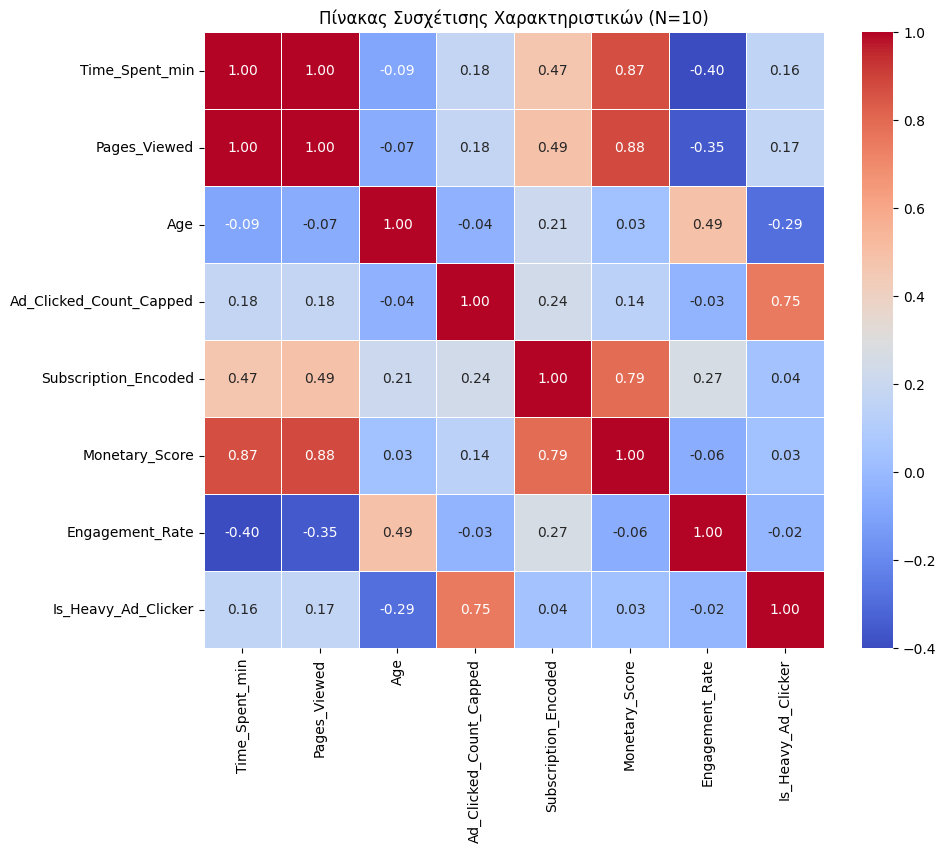

In [ ]:
# Επιλογή των αριθμητικών/κωδικοποιημένων χαρακτηριστικών για ανάλυση
features_to_analyze = [
    'Time_Spent_min', 'Pages_Viewed', 'Age', 'Ad_Clicked_Count_Capped',
    'Subscription_Encoded', 'Monetary_Score', 'Engagement_Rate',
    'Is_Heavy_Ad_Clicker'
]
correlation_matrix = df_encoded[features_to_analyze].corr()

# Οπτικοποίηση Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Πίνακας Συσχέτισης Χαρακτηριστικών (N=10)')
plt.savefig('correlation_heatmap_N10.png')
plt.show()

## 3.2. Διασταυρούμενη Ανάλυση (Cross-Tabulation)
# Στόχος: Ανάλυση της σχέσης του Flagged χαρακτηριστικού με τη μεταβλητή στόχου.


Ποσοστά Conversion (ανά στήλη) σε σχέση με το αν ο χρήστης είναι Heavy Ad Clicker (0=Όχι, 1=Ναι):

Conversion_Type      Full_Sale  None  Trial
Is_Heavy_Ad_Clicker                        
0                         44.4  33.3   22.2
1                          0.0   0.0  100.0


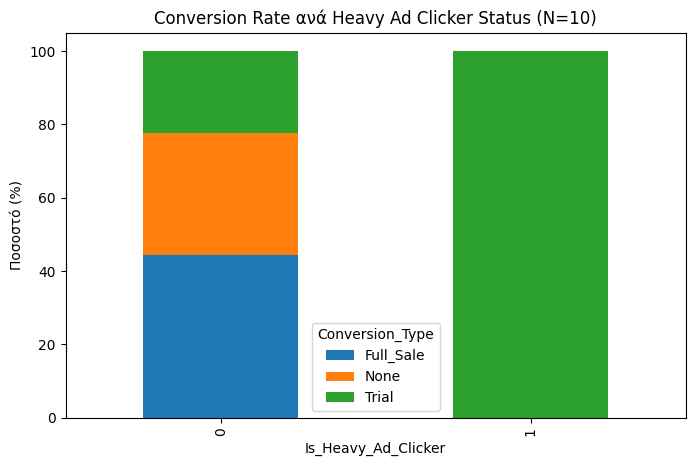

In [ ]:
# Σχέση μεταξύ Heavy Clickers (νέο Flag) και Conversion Type (Στόχος)
cross_tab = pd.crosstab(df_encoded['Is_Heavy_Ad_Clicker'], df_encoded['Conversion_Type'], normalize='index') * 100

print("\nΠοσοστά Conversion (ανά στήλη) σε σχέση με το αν ο χρήστης είναι Heavy Ad Clicker (0=Όχι, 1=Ναι):\n")
print(cross_tab.round(1))

# Οπτικοποίηση Cross-Tabulation
cross_tab.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Conversion Rate ανά Heavy Ad Clicker Status (N=10)')
plt.ylabel('Ποσοστό (%)')
plt.savefig('conversion_cross_tab_N10.png')
plt.show()

# Τελική Ερώτηση για Συζήτηση (Feature Selection)
### Βάσει του $\text{Heatmap}$ (Άσκηση 3.1), διαπιστώνεται υψηλή συσχέτιση (Πολυσυγγραμμικότητα) μεταξύ των $\text{`Time_Spent_min`}$ και $\text{`Pages_Viewed`}$.
### Ποια χαρακτηριστικά από τα τρία (Time\_Spent\_min, Pages\_Viewed, Engagement\_Rate) θα επιλέγατε να κρατήσετε στο τελικό dataset και γιατί; (Λάβετε υπόψη σας την Πολυσυγγραμμικότητα και την πληροφοριακή αξία του νέου χαρακτηριστικού.)